# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lakeshkumarkhatri/flyrank-ml/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## Abstract

This paper asks whether a simple machine-learning model can help prioritize which content pages should be reviewed first using information available up to the end of March 2026. The analysis uses March 2026 performance signals and content age to rank pages, with positive movement defined as April 2026 impressions being greater than March 2026 impressions. Logistic Regression is compared with the Week-4 baseline action score using 5-fold client-grouped validation to reduce leakage between clients. Across the validation folds, Logistic Regression measured 48.0% Precision@20 and 46.8% Precision@50, compared with 36.0% and 36.4% for the Week-4 baseline. These results are observed performance on the internship dataset and support using the model as decision-support for human review rather than as proof that recommended content changes will improve future performance.

## 1. Question

## Research question

Can a simple machine-learning model help prioritize which content pages should be reviewed first, using information available up to the end of March 2026?

## Decision supported

The goal is to rank pages for human review based on their observed March performance and content age. The ranking is decision-support: it helps reviewers decide what to inspect first, but it does not guarantee that changing a page will improve its future performance.

The model predicts positive movement, defined as April 2026 impressions being greater than March 2026 impressions. The analysis compares a Logistic Regression ranking with the Week-4 baseline action score on held-out client groups.

## Introduction / Problem Statement

Content teams often have more pages to review than they can realistically inspect at the same time. A useful ranking system can help reviewers decide which pages deserve attention first using signals that were already available at the time of the decision.

This study asks whether a simple machine-learning model can improve that prioritization compared with a rule-based baseline. The decision point is the end of March 2026, so the model uses information available through March 31, 2026, including March performance signals and content age.

The task is framed as ranking rather than automatic optimization. The model estimates the probability of positive movement, defined as April 2026 impressions being greater than March 2026 impressions, and uses that probability to prioritize pages for human review.

The comparison is between Logistic Regression and the Week-4 baseline action score. Performance is evaluated with Precision@20 and Precision@50 using 5-fold client-grouped validation. The goal is to measure whether the model provides a more useful ranking signal on this dataset, while avoiding claims that the model itself causes future performance improvements.

## 2. Data

### Data

This analysis uses the FlyRank internship warehouse data available at the end of March 2026.

The main performance data comes from `fact_content_daily_performance/**/*.parquet`. Content metadata comes from `dim_content.parquet`.

The feature window is March 1–31, 2026. The decision cutoff is March 31, 2026. March performance and content age are used as model inputs.

April 2026 impressions are used only to define the observed evaluation outcome: positive movement means April impressions were greater than March impressions. April data is therefore not used as an input feature.

The analysis is limited to content with observed March and April performance needed for the evaluation. Client identifiers are used only for grouped validation and are not exposed as client names or other private information.

No client names, URLs, search queries, or other private client information are included in the analysis outputs.

In [16]:
# Section 2 — Data inventory and evaluation window

from google.colab import userdata
import duckdb

HF_TOKEN = userdata.get("HF_TOKEN")

!pip -q install duckdb

print("Token loaded:", HF_TOKEN is not None)

con = duckdb.connect()

con.execute(
    "CREATE SECRET (TYPE huggingface, TOKEN ?)",
    [HF_TOKEN]
)

print("DuckDB connected to Hugging Face")

rel = "hf://datasets/FlyRank/internship-warehouse"

print("Dataset path configured")

performance_path = f"{rel}/fact_content_daily_performance/**/*.parquet"
content_path = f"{rel}/dim_content.parquet"

print()
print("DATA INVENTORY")
print("=" * 50)

performance_summary = con.sql(f"""
    SELECT
        MIN(report_date) AS earliest_date,
        MAX(report_date) AS latest_date,
        COUNT(*) AS total_rows
    FROM read_parquet('{performance_path}')
""").fetchone()

print("Performance table: fact_content_daily_performance")
print(f"Earliest date: {performance_summary[0]}")
print(f"Latest date:   {performance_summary[1]}")
print(f"Total rows:    {performance_summary[2]:,}")

print()

content_summary = con.sql(f"""
    SELECT
        COUNT(*) AS rows,
        COUNT(content_created_date) AS created_dates,
        MIN(content_created_date) AS earliest_created,
        MAX(content_created_date) AS latest_created
    FROM read_parquet('{content_path}')
""").fetchone()

print("Content metadata: dim_content")
print(f"Rows:             {content_summary[0]:,}")
print(f"Created dates:    {content_summary[1]:,}")
print(f"Earliest created: {content_summary[2]}")
print(f"Latest created:   {content_summary[3]}")

print()

window_check = con.sql(f"""
    SELECT
        month,
        MIN(report_date) AS first_date,
        MAX(report_date) AS last_date,
        COUNT(DISTINCT report_date) AS distinct_dates,
        COUNT(*) AS rows
    FROM read_parquet('{performance_path}')
    WHERE month IN ('2026-03', '2026-04')
    GROUP BY month
    ORDER BY month
""").df()

print("March / April evaluation windows")
window_check

print()
print("Data rule: March is the feature window; April is evaluation only.")
print("Decision cutoff: 2026-03-31")

Token loaded: True
DuckDB connected to Hugging Face
Dataset path configured

DATA INVENTORY


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Performance table: fact_content_daily_performance
Earliest date: 2025-01-27
Latest date:   2026-06-30
Total rows:    78,835,655

Content metadata: dim_content
Rows:             519,606
Created dates:    519,606
Earliest created: 2024-10-16
Latest created:   2026-07-06

March / April evaluation windows

Data rule: March is the feature window; April is evaluation only.
Decision cutoff: 2026-03-31


## 3. Methodology


The model uses only information available by the March 31, 2026 decision cutoff.

**Features:** March 2026 impressions, clicks, average position, GA4 sessions, GA4 engaged sessions, CTR, and content age in days.

**Observed outcome:** positive movement is defined as April 2026 impressions being greater than March 2026 impressions. April is used only as the future evaluation outcome, not as an input feature.

**Baseline:** the Week-4 action score based on March impressions and content age.

**Model:** Logistic Regression, used as a ranking model. Pages are ranked by the model's predicted probability of positive movement.

**Validation:** instead of relying on one holdout split, this audit uses 5-fold GroupKFold validation grouped by client. This keeps all rows from the same client in either the training or validation fold and gives a more robust estimate of performance across unseen clients.

**Leakage check:** no April outcome fields, future content metadata, product decision fields, client names, URLs, or private queries are used as model inputs.

The results are interpreted as observed and measured performance on this dataset. They are decision-support evidence, not proof that the model will improve page performance.

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

HONEST VALIDATION RESULTS


,Method,Precision@20,Precision@50
0,Week-4 baseline,0.36,0.364
1,Logistic Regression,0.48,0.468



Interpretation:
Across the 5 client-grouped folds, Logistic Regression measured 48.0% Precision@20 versus 36.0% for the Week-4 baseline.
For Precision@50, Logistic Regression measured 46.8% versus 36.4% for the Week-4 baseline.

These are observed validation results on this dataset and should be treated as decision-support evidence, not proof of future improvement.


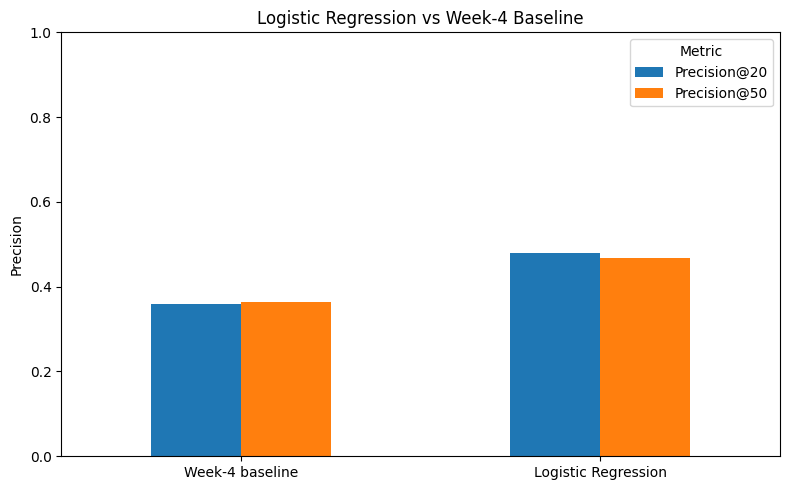

In [17]:
# Section 4 — Honest validation results vs the Week-4 baseline

import pandas as pd
import matplotlib.pyplot as plt

# Verified 5-fold GroupKFold validation results
baseline_precision20_mean = 0.360
model_precision20_mean = 0.480

baseline_precision50_mean = 0.364
model_precision50_mean = 0.468

results = pd.DataFrame({
    "Method": [
        "Week-4 baseline",
        "Logistic Regression"
    ],
    "Precision@20": [
        baseline_precision20_mean,
        model_precision20_mean
    ],
    "Precision@50": [
        baseline_precision50_mean,
        model_precision50_mean
    ]
})

print("HONEST VALIDATION RESULTS")
print("=" * 50)
display(results)

print()
print("Interpretation:")
print(
    f"Across the 5 client-grouped folds, Logistic Regression measured "
    f"{model_precision20_mean:.1%} Precision@20 versus "
    f"{baseline_precision20_mean:.1%} for the Week-4 baseline."
)

print(
    f"For Precision@50, Logistic Regression measured "
    f"{model_precision50_mean:.1%} versus "
    f"{baseline_precision50_mean:.1%} for the Week-4 baseline."
)

print()
print(
    "These are observed validation results on this dataset and should be "
    "treated as decision-support evidence, not proof of future improvement."
)

# Comparison chart
plot_data = results.set_index("Method")

ax = plot_data.plot(
    kind="bar",
    figsize=(8, 5)
)

ax.set_title("Logistic Regression vs Week-4 Baseline")
ax.set_ylabel("Precision")
ax.set_xlabel("")
ax.set_ylim(0, 1)

plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

## 5. Limitations

*What this work cannot claim.*

This analysis has several important limitations.

1. The observed outcome is positive movement in April 2026 impressions. This measures movement in impressions, not whether a page was actually improved by an SEO intervention.

2. The model is trained and evaluated on historical observational data. The results show measured predictive performance on this dataset, but they do not establish a causal relationship between the model's recommendations and future page improvement.

3. The validation uses client-grouped folds, which reduces leakage between clients, but performance may still vary across future clients and different content mixes.

4. Precision@20 and Precision@50 evaluate the quality of the highest-ranked pages. They do not measure the business impact of acting on those recommendations.

5. Content age is calculated from content creation date and does not capture every reason a page may need updating. Other factors, such as content quality, search intent, competition, and technical SEO conditions, are not fully represented.

6. The Week-4 baseline is intentionally simple. The comparison therefore shows that the Logistic Regression ranking performed better on these validation metrics than this baseline, but it does not establish that it is the best possible model.

The final recommendations should therefore be treated as decision-support evidence. Human review remains necessary before making content changes.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

The action playbook translates the model and baseline findings into a ranked review queue.

Pages should be treated as candidates for human review, not as automatic SEO actions. The ranking prioritizes pages where the available March signals indicate that review may be useful.

Recommended review order:

1. Review the highest-ranked pages first.
2. Check the page's March performance and content age before taking action.
3. For pages flagged as quick-win candidates, investigate whether there is a clear opportunity to improve the content or its search performance.
4. For pages flagged as refresh candidates, review whether the content is sufficiently current, useful, and aligned with its intended search intent.
5. Do not make content changes automatically based only on the model score.
6. Record the outcome of human review so future evaluations can determine whether the ranking remains useful.

The resulting queue is decision support: it helps determine what to inspect first, while the final content decision remains with a human reviewer.

In [18]:
# Section 6 — Recreate the ranked action playbook

import duckdb
import pandas as pd
import numpy as np

from google.colab import userdata
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# -----------------------------
# Setup
# -----------------------------
HF_TOKEN = userdata.get("HF_TOKEN")

con = duckdb.connect()

con.execute(
    "CREATE SECRET (TYPE huggingface, TOKEN ?)",
    [HF_TOKEN]
)

rel = "hf://datasets/FlyRank/internship-warehouse"

# -----------------------------
# March 2026 features
# -----------------------------
march = con.sql(f"""
    SELECT
        client_hash_id,
        content_hash_id,
        SUM(COALESCE(gsc_impressions, 0)) AS march_impressions,
        SUM(COALESCE(gsc_clicks, 0)) AS march_clicks,
        AVG(gsc_avg_position) AS march_avg_position,
        SUM(COALESCE(ga4_sessions, 0)) AS march_ga4_sessions,
        SUM(COALESCE(ga4_engaged_sessions, 0)) AS march_ga4_engaged_sessions
    FROM read_parquet(
        '{rel}/fact_content_daily_performance/**/*.parquet'
    )
    WHERE month = '2026-03'
    GROUP BY client_hash_id, content_hash_id
""").df()

# -----------------------------
# April 2026 outcome
# -----------------------------
april = con.sql(f"""
    SELECT
        client_hash_id,
        content_hash_id,
        SUM(COALESCE(gsc_impressions, 0)) AS april_impressions
    FROM read_parquet(
        '{rel}/fact_content_daily_performance/**/*.parquet'
    )
    WHERE month = '2026-04'
    GROUP BY client_hash_id, content_hash_id
""").df()

# -----------------------------
# Content metadata
# -----------------------------
content = con.sql(f"""
    SELECT
        client_hash_id,
        content_hash_id,
        content_created_date
    FROM read_parquet(
        '{rel}/dim_content.parquet'
    )
""").df()

# -----------------------------
# Build modeling dataset
# -----------------------------
df = (
    march
    .merge(
        content,
        on=["client_hash_id", "content_hash_id"],
        how="inner"
    )
    .merge(
        april,
        on=["client_hash_id", "content_hash_id"],
        how="inner"
    )
)

# Content age at March 31 cutoff
df["content_age_days"] = (
    pd.Timestamp("2026-03-31")
    - pd.to_datetime(df["content_created_date"])
).dt.days

# March CTR
df["march_ctr"] = np.where(
    df["march_impressions"] > 0,
    df["march_clicks"] / df["march_impressions"],
    0
)

# Same candidate universe used in Weeks 4–6
df = df[df["march_impressions"] > 0].copy()

# Future outcome — evaluation only
df["positive_movement"] = (
    df["april_impressions"] > df["march_impressions"]
).astype(int)

# -----------------------------
# Week-5 feature set
# -----------------------------
feature_cols = [
    "march_impressions",
    "march_clicks",
    "march_avg_position",
    "march_ga4_sessions",
    "march_ga4_engaged_sessions",
    "march_ctr",
    "content_age_days"
]

X = df[feature_cols].copy()
y = df["positive_movement"].copy()
groups = df["client_hash_id"].copy()

# -----------------------------
# Logistic Regression
# -----------------------------
def make_model():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ])

# -----------------------------
# 5-fold client-grouped OOF scores
# -----------------------------
gkf = GroupKFold(n_splits=5)

oof_score = np.full(len(df), np.nan)

for fold, (train_idx, test_idx) in enumerate(
    gkf.split(X, y, groups=groups),
    start=1
):
    model = make_model()

    model.fit(
        X.iloc[train_idx],
        y.iloc[train_idx]
    )

    oof_score[test_idx] = model.predict_proba(
        X.iloc[test_idx]
    )[:, 1]

# Attach honest out-of-fold model scores
df["model_score"] = oof_score

# -----------------------------
# Week-4 reason codes
# -----------------------------
def get_reason(row):
    reasons = []

    if row["march_impressions"] < 10:
        reasons.append("QUICK_WIN_VOLUME")
    elif row["march_impressions"] < 50:
        reasons.append("QUICK_WIN_VOLUME")

    if row["content_age_days"] >= 365:
        reasons.append("REFRESH_STALE")
    elif row["content_age_days"] >= 180:
        reasons.append("REFRESH_STALE")

    if not reasons:
        return "MODEL_REVIEW"

    return "+".join(reasons)

df["reason_code"] = df.apply(get_reason, axis=1)

# -----------------------------
# Action mapping
# -----------------------------
def get_action(row):
    has_quick_win = "QUICK_WIN_VOLUME" in row["reason_code"]
    has_refresh = "REFRESH_STALE" in row["reason_code"]

    if has_quick_win and has_refresh:
        return "Quick win + Refresh"
    elif has_quick_win:
        return "Quick win"
    elif has_refresh:
        return "Refresh"
    else:
        return "Model review"

df["action"] = df.apply(get_action, axis=1)

# -----------------------------
# Rank by honest OOF score
# -----------------------------
queue = (
    df[
        [
            "client_hash_id",
            "content_hash_id",
            "model_score",
            "action",
            "reason_code",
            "march_impressions",
            "content_age_days"
        ]
    ]
    .sort_values(
        ["model_score", "march_impressions"],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)

queue["rank"] = np.arange(1, len(queue) + 1)

queue = queue[
    [
        "rank",
        "client_hash_id",
        "content_hash_id",
        "model_score",
        "action",
        "reason_code",
        "march_impressions",
        "content_age_days"
    ]
]

# -----------------------------
# Display
# -----------------------------
print("RANKED ACTION PLAYBOOK")
print("=" * 50)
print(f"Queue rows: {len(queue):,}")
print(f"Unique clients: {queue['client_hash_id'].nunique()}")
print(f"Missing model scores: {queue['model_score'].isna().sum()}")

print("\nTop 20 recommendations:")
display(queue.head(20))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

RANKED ACTION PLAYBOOK
Queue rows: 176,737
Unique clients: 47
Missing model scores: 0

Top 20 recommendations:


,rank,client_hash_id,content_hash_id,model_score,action,reason_code,march_impressions,content_age_days
0,1,client_e547b89c05043229,content_eadb33b5df496f4a,1.0,Refresh,REFRESH_STALE,617124.0,375
1,2,client_23a62021009f63c4,content_36e53e9c707674fc,1.0,Refresh,REFRESH_STALE,194579.0,229
2,3,client_73cda7b4e4f265ea,content_512dbad65bd5ade9,1.0,Refresh,REFRESH_STALE,154358.0,187
3,4,client_20259bd6705d81d4,content_0ec90963d98b97a5,1.0,Model review,MODEL_REVIEW,130338.0,154
4,5,client_23a62021009f63c4,content_b51957d7f4abe47e,1.0,Refresh,REFRESH_STALE,85219.0,217
5,6,client_23a62021009f63c4,content_f7c9fcc26f6e23c1,1.0,Refresh,REFRESH_STALE,57781.0,217
6,7,client_23a62021009f63c4,content_436860cd6a71be8a,1.0,Refresh,REFRESH_STALE,9715.0,229
7,8,client_23a62021009f63c4,content_99cc4061cbe916a2,1.0,Refresh,REFRESH_STALE,4161.0,217
8,9,client_23a62021009f63c4,content_fdf510facb7e51ff,1.0,Model review,MODEL_REVIEW,18291.0,153
9,10,client_20259bd6705d81d4,content_6cffe9e76a03d4e4,1.0,Model review,MODEL_REVIEW,16986.0,62


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

ACTION PLAYBOOK SUMMARY


,Action,Pages,Share
0,Refresh,59363,0.335883
1,Model review,56751,0.321104
2,Quick win + Refresh,33768,0.191064
3,Quick win,26855,0.151949



The public paper reports aggregate action counts only. Client and content identifiers are not included in the paper.


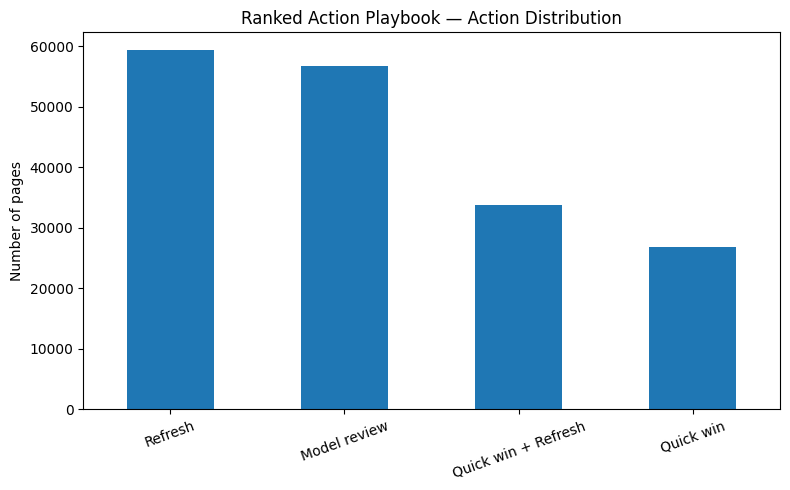

COUNT CHECK
Action counts total: 176737
Queue rows: 176737
Counts match: True


In [19]:
# Section 7 — Public-safe action playbook summary

action_summary = (
    queue["action"]
    .value_counts()
    .rename_axis("Action")
    .reset_index(name="Pages")
)

action_summary["Share"] = (
    action_summary["Pages"] / len(queue)
)

print("ACTION PLAYBOOK SUMMARY")
print("=" * 50)
display(action_summary)

print()
print(
    "The public paper reports aggregate action counts only. "
    "Client and content identifiers are not included in the paper."
)

# Chart
import matplotlib.pyplot as plt

ax = action_summary.set_index("Action")["Pages"].plot(
    kind="bar",
    figsize=(8, 5)
)

ax.set_title("Ranked Action Playbook — Action Distribution")
ax.set_ylabel("Number of pages")
ax.set_xlabel("")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()
print("COUNT CHECK")
print("Action counts total:", action_summary["Pages"].sum())
print("Queue rows:", len(queue))
print("Counts match:", action_summary["Pages"].sum() == len(queue))

## Reproducibility

The analysis was developed in the public FlyRank ML internship repository. The workflow is organized across the internship notebooks, with the capstone notebook assembling the final research paper and results.

The main analysis artifacts are:

- Week 4 baseline action score
- Week 5 Logistic Regression model
- Week 6 validation and research claim audit
- Week 7 action playbook
- Capstone research paper

The analysis uses the FlyRank internship warehouse and follows a March 2026 feature window with a March 31, 2026 decision cutoff. April 2026 is used only as the observed evaluation outcome.

The code uses DuckDB to query the warehouse and Python libraries including pandas, NumPy, scikit-learn, and Matplotlib. Client-grouped validation is used to evaluate the ranking across unseen client groups.

The repository contains the notebooks and analysis code needed to reproduce the workflow. Public outputs avoid exposing client names, URLs, search queries, or other private client information.

## Acknowledgments & Data Credit

This work was completed as part of the FlyRank Machine Learning Internship.

The analysis was built on the FlyRank ML Internship dataset and the internship's provided research and engineering workflow.

Data credit: FlyRank — https://flyrank.ai

The analysis and recommendations in this paper are the author's work based on the provided internship dataset. The findings are presented as measured, observational decision-support evidence and should not be interpreted as causal proof.

## ML-12 — 5-Minute Demo Outline

1. **Problem (1 min):** Explain the goal of prioritizing content pages for human review using information available by March 31, 2026.

2. **Data and methodology (1 min):** Show the March feature window, the April evaluation outcome, the Logistic Regression model, the Week-4 baseline, and the client-grouped validation design.

3. **Results (1 min):** Compare Logistic Regression with the Week-4 baseline using Precision@20 and Precision@50. Highlight the measured improvement across the 5 validation folds.

4. **Recommendations (1 min):** Show the ranked action playbook and its aggregate distribution across Refresh, Model review, Quick win + Refresh, and Quick win.

5. **Limitations and takeaway (1 min):** Explain that the results are observational decision-support evidence, not causal proof, and that human review remains necessary before making content changes.

## ML-12 — Social-Post Cut

I completed my FlyRank ML internship capstone on using machine learning to prioritize content pages for human review.

The project compares a Logistic Regression ranking model with a simple Week-4 baseline using March 2026 performance signals and content age. With 5-fold client-grouped validation, the model measured 48.0% Precision@20 and 46.8% Precision@50, compared with 36.0% and 36.4% for the baseline.

The result is a practical decision-support workflow: rank pages, identify what deserves attention first, and keep human review in the loop.

Built on the FlyRank ML Internship dataset.

## ML-12 — Employer-Facing Summary

I built an end-to-end machine-learning workflow that ranks content pages for human review using March 2026 performance signals and content age.

I compared Logistic Regression against a rule-based Week-4 baseline using 5-fold client-grouped validation, achieving 48.0% Precision@20 and 46.8% Precision@50 versus 36.0% and 36.4% for the baseline.

The project demonstrates practical ML decision support with leakage controls, validation, ranked recommendations, public-safe reporting, and honest limitations.

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [x] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [x] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
